# Проект по SQL - Анализ базы данных сервиса чтения книг по подписке


**Цель:** Найти данные, которые помогут сформулировать ценностное предложение для нового продукта сервиса чтения книг по подписке.

**Задачи:**
1. Посчитать, сколько книг вышло после 1 января 2000 года;
2. Для каждой книги посчитать количество обзоров и среднюю оценку;
3. Определить издательство, которое выпустило наибольшее число книг толще 50 страниц (исключение из анализа брошюр);
4. Определить автора с самой высокой средней оценкой книг — учитывать только книги с 50 и более оценками;
5. Посчитать среднее количество обзоров от пользователей, которые поставили больше 48 оценок.

**Описание данных**
* Таблица `books` - cодержит данные о книгах:
    * `book_id` — идентификатор книги;
    * `author_id` — идентификатор автора;
    * `title` — название книги;
    * `num_pages` — количество страниц;
    * `publication_date` — дата публикации книги;
    * `publisher_id` — идентификатор издателя.

* Таблица `authors` - cодержит данные об авторах:
    * `author_id` — идентификатор автора;
    * `author` — имя автора.

* Таблица `publishers` - cодержит данные об издательствах:
    * `publisher_id` — идентификатор издательства;
    * `publisher` — название издательства;

* Таблица `ratings` - cодержит данные о пользовательских оценках книг:
    * `rating_id` — идентификатор оценки;
    * `book_id` — идентификатор книги;
    * `username` — имя пользователя, оставившего оценку;
    * `rating` — оценка книги.

* Таблица `reviews` - cодержит данные о пользовательских обзорах:
    * `review_id` — идентификатор обзора;
    * `book_id` — идентификатор книги;
    * `username` — имя автора обзора;
    * `text` — текст обзора.
    
**Схема данных:**
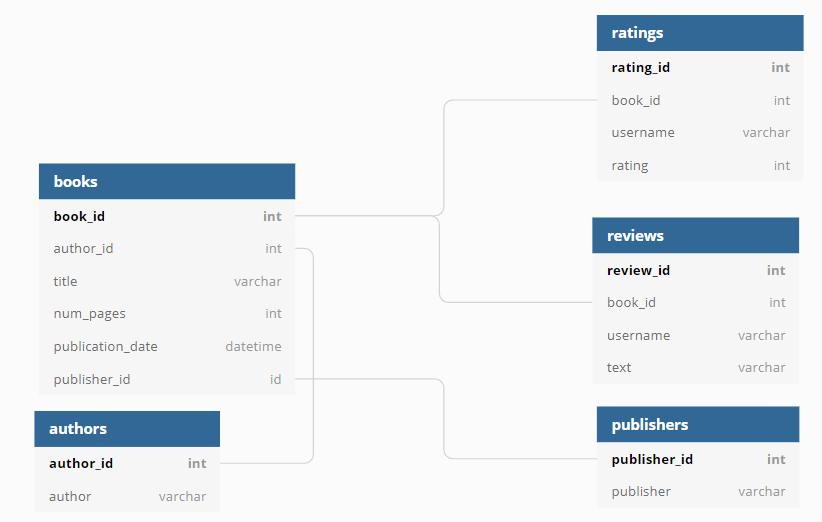

## Загрузка библиотек и подключение к данным

Загрузим необходимые библиотеки:

In [1]:
import pandas as pd
from sqlalchemy import text, create_engine

import matplotlib.pyplot as plt
import seaborn as sns

Сконфигурируем подключение к базе данных:

In [ ]:
db_config = {'user': '', # имя пользователя
'pwd': '', # пароль
'host': '',
'port': 0000, # порт подключения
'db': ''} # название базы данных

connection_string = 'postgresql://{user}:{pwd}@{host}:{port}/{db}'.format(**db_config)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

Создадим подключение:

In [3]:
con=engine.connect()

Проверим подключение:

In [4]:
con

Подключение выполнено.

## Ознакомление с таблицами базы данных

Таблицу `books` загрузили в предыдущем разделе.

Для удобства дальнейшей работы напишем функцию для выполнения запросов:

In [5]:
def execute_query(query, connector=engine.connect()):
    return pd.io.sql.read_sql(sql=text(query), con = connector)

### Таблица `books`

Запрос к БД:

In [6]:
query = '''
SELECT * 
FROM books
LIMIT 5
'''

Выполнение запроса и вывод результата:

In [7]:
execute_query(query)

,book_id,author_id,title,num_pages,publication_date,publisher_id
0,1,546,'Salem's Lot,594,2005-11-01,93
1,2,465,1 000 Places to See Before You Die,992,2003-05-22,336
2,3,407,13 Little Blue Envelopes (Little Blue Envelope...,322,2010-12-21,135
3,4,82,1491: New Revelations of the Americas Before C...,541,2006-10-10,309
4,5,125,1776,386,2006-07-04,268


### Таблица `authors`

Запрос к БД:

In [8]:
query = '''
SELECT * 
FROM authors
LIMIT 5
'''

Выполнение запроса и вывод результата:

In [9]:
execute_query(query)

,author_id,author
0,1,A.S. Byatt
1,2,Aesop/Laura Harris/Laura Gibbs
2,3,Agatha Christie
3,4,Alan Brennert
4,5,Alan Moore/David Lloyd


### Таблица `publishers`

Запрос к БД:

In [10]:
query = '''
SELECT * 
FROM publishers
LIMIT 5
'''

Выполнение запроса и вывод результата:

In [11]:
execute_query(query)

,publisher_id,publisher
0,1,Ace
1,2,Ace Book
2,3,Ace Books
3,4,Ace Hardcover
4,5,Addison Wesley Publishing Company


### Таблица `ratings`

Запрос к БД:

In [12]:
query = '''
SELECT * 
FROM ratings
LIMIT 5
'''

Выполнение запроса и вывод результата:

In [13]:
execute_query(query)

,rating_id,book_id,username,rating
0,1,1,ryanfranco,4
1,2,1,grantpatricia,2
2,3,1,brandtandrea,5
3,4,2,lorichen,3
4,5,2,mariokeller,2


### Таблица `reviews`

Запрос к БД:

In [14]:
query = '''
SELECT * 
FROM reviews
LIMIT 5
'''

Выполнение запроса и вывод результата:

In [15]:
execute_query(query)

,review_id,book_id,username,text
0,1,1,brandtandrea,Mention society tell send professor analysis. ...
1,2,1,ryanfranco,Foot glass pretty audience hit themselves. Amo...
2,3,2,lorichen,Listen treat keep worry. Miss husband tax but ...
3,4,3,johnsonamanda,Finally month interesting blue could nature cu...
4,5,3,scotttamara,Nation purpose heavy give wait song will. List...


## Исследование базы данных

### Расчёт количества книг, вышедших с 1 января 2000 года

**Задача:** Посчитать, сколько книг вышло после 1 января 2000 года

Запрос к БД:   

In [16]:
books_since_2000 = '''
SELECT COUNT(DISTINCT book_id)
FROM books
WHERE publication_date >='2000-01-01'
'''

Выполним запрос:

In [17]:
execute_query(books_since_2000)

,count
0,821


Получили, что с 1 января 2000 годы вышла 821 книга.

### Расчёт количества обзоров и средней оценки для каждой книги

**Задача:** Для каждой книги посчитать количество обзоров и среднюю оценку
    
Запрос к БД:

In [110]:
books_reviews = '''
WITH book_rewiews AS (
SELECT book_id,
       COUNT(review_id) AS review_num
FROM reviews
GROUP BY book_id
),
avg_rating AS (
SELECT book_id,
       AVG(rating) AS avg_rating
FROM ratings
GROUP BY book_id
)
SELECT DISTINCT b.book_id,
       b.title,
       br.review_num,
       ar.avg_rating
FROM books b
LEFT JOIN book_rewiews br ON b.book_id=br.book_id
LEFT JOIN avg_rating ar ON b.book_id=ar.book_id 
ORDER BY br.review_num DESC, ar.avg_rating DESC, b.book_id ASC;
'''

Выполним запрос и сохраним результат в переменную: 

In [111]:
books_rewiews_and_ratings = execute_query(books_reviews)

Отобразим первые 10 записей:

In [112]:
books_rewiews_and_ratings.head(10)

,book_id,title,review_num,avg_rating
0,672,The Cat in the Hat and Other Dr. Seuss Favorites,NaN,5.000000
1,191,Disney's Beauty and the Beast (A Little Golden...,NaN,4.000000
2,221,Essential Tales and Poems,NaN,4.000000
3,387,Leonardo's Notebooks,NaN,4.000000
4,83,Anne Rice's The Vampire Lestat: A Graphic Novel,NaN,3.666667
5,808,The Natural Way to Draw,NaN,3.000000
6,948,Twilight (Twilight #1),7.0,3.662500
7,302,Harry Potter and the Prisoner of Azkaban (Harr...,6.0,4.414634
8,299,Harry Potter and the Chamber of Secrets (Harry...,6.0,4.287500
9,656,The Book Thief,6.0,4.264151


Отобразим последние 10 записей:

In [113]:
books_rewiews_and_ratings

,book_id,title,review_num,avg_rating
0,672,The Cat in the Hat and Other Dr. Seuss Favorites,NaN,5.000000
1,191,Disney's Beauty and the Beast (A Little Golden...,NaN,4.000000
2,221,Essential Tales and Poems,NaN,4.000000
3,387,Leonardo's Notebooks,NaN,4.000000
4,83,Anne Rice's The Vampire Lestat: A Graphic Novel,NaN,3.666667
...,...,...,...,...
995,187,Debt of Honor (Jack Ryan #7),1.0,3.000000
996,446,Moo Baa La La La!,1.0,3.000000
997,2,1 000 Places to See Before You Die,1.0,2.500000
998,318,History of Beauty,1.0,2.500000


* Посчитали для каждой книги количество обзоров и средний рейтинг, вывели в порядке убывания количества обзоров, рейтинга и по возрастанию идентификатора книги.
* Для шести книг не оказалось обзоров.
* Максимальное количество обзоров у одной книги - 7, минимальное - 0.
* Максимальный рейтинг - 5, минимальный - 2.5

Визуализируем распределение количества обзоров и рейтинг:

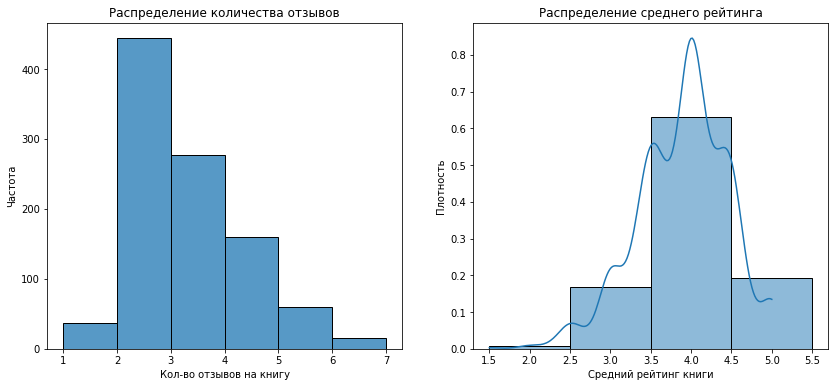

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(data=books_rewiews_and_ratings, 
                     x='review_num', 
                     bins=1, 
                     binwidth=1,
                     ax=axes[0],
                     palette='muted')

sns.histplot(data=books_rewiews_and_ratings, 
                     x='avg_rating', 
                     bins=10, 
                     stat='density', 
                     common_norm=False, 
                     kde=True, 
                     binwidth=1,
                     ax=axes[1],
                     palette='muted')

axes[0].set_title('Распределение количества отзывов')
axes[0].set_xlabel('Кол-во отзывов на книгу')
axes[0].set_ylabel('Частота')

axes[1].set_title('Распределение среднего рейтинга')
axes[1].set_xlabel('Средний рейтинг книги')
axes[1].set_ylabel('Плотность')

plt.show();

* Чаще всего встречается от 2 до 5 отзывов на книгу.
* Большая часть рейтингов книг находится в диапазоне 3.5-4.5.

### Определение издательства, которое выпустило наибольшее число книг объемом более 50 страниц

**Задача:** Определить издательство, которое выпустило наибольшее число книг толще 50 страниц (исключение из анализа брошюр)

Запрос к БД:

In [23]:
most_productivity_publisher = '''
WITH big_books AS (
SELECT book_id
FROM books
WHERE num_pages > 50 
),
books_by_publishers AS (
SELECT publisher_id,
       COUNT(book_id) as book_num
FROM books
WHERE book_id IN (SELECT book_id FROM big_books)
GROUP BY publisher_id
ORDER BY COUNT(book_id) DESC
LIMIT 1
)
SELECT p.publisher,
       bbp.book_num
FROM books_by_publishers bbp
JOIN publishers p ON bbp.publisher_id=p.publisher_id
'''

Выполним запрос:

In [24]:
execute_query(most_productivity_publisher)

,publisher,book_num
0,Penguin Books,42


Издательство **"Penguin Books"** выпустило **42** книги объемом более 50 страниц, что является самым высоким результатом среди других издательств.

### Определение автора с самой высокой средней оценкой книг (книги с 50 и более оценками)

**Задача:** Определить автора с самой высокой средней оценкой книг — учитывать только книги с 50 и более оценками

Запрос к БД:

In [124]:
best_author = '''
WITH books_with_50_marks AS (
SELECT book_id,
       COUNT(rating_id) AS marks_num
FROM ratings
GROUP BY book_id
HAVING COUNT(rating_id)>=50
), books_ratings AS (
SELECT book_id,
       AVG(rating) AS avg_rating
FROM ratings
WHERE book_id IN (SELECT book_id FROM books_with_50_marks)
GROUP BY book_id
ORDER BY AVG(rating) DESC
)
SELECT a.author_id,
       a.author,
       AVG(br.avg_rating) AS avg_rating      
FROM books b
JOIN authors a ON b.author_id=a.author_id
JOIN books_ratings br ON b.book_id=br.book_id
WHERE b.book_id IN (SELECT book_id FROM books_ratings)
GROUP BY a.author_id
ORDER BY AVG(br.avg_rating) DESC
LIMIT 1
'''

Выполним запрос:

In [125]:
execute_query(best_author)

,author_id,author,avg_rating
0,236,J.K. Rowling/Mary GrandPré,4.283844


Получили, что **J.K. Rowling/Mary GrandPré** - автор с самой высокой средней оценкой книг (для книг с 50 и более оценками).

Посмотрим какие книги написал данный автор:

In [27]:
books_by_best_author = '''
SELECT title,
       num_pages,
       publication_date
FROM books
WHERE author_id=236
'''

execute_query(books_by_best_author)

,title,num_pages,publication_date
0,Harry Potter Boxed Set Books 1-5 (Harry Potte...,2690,2004-09-13
1,Harry Potter and the Chamber of Secrets (Harry...,341,1999-06-02
2,Harry Potter and the Half-Blood Prince (Harry ...,652,2006-09-16
3,Harry Potter and the Order of the Phoenix (Har...,870,2004-09-01
4,Harry Potter and the Prisoner of Azkaban (Harr...,435,2004-05-01


Получили, что **J.K. Rowling/Mary GrandPré** - автор книг о Гарри Поттере

### Расчёт среднего количества обзоров от пользователей, которые поставили больше 48 оценок

**Задача:**Посчитать среднее количество обзоров от пользователей, которые поставили больше 48 оценок.

Запрос к БД:

In [28]:
avg_reviews_by_users_with_48_marks = '''
WITH users_with_48_marks AS (
    SELECT username
    FROM ratings
    GROUP BY username
    HAVING COUNT(rating_id)>48
),
reviews_nums AS (
SELECT username,
       COUNT(review_id) AS reviews_num
FROM reviews
WHERE username IN (SELECT username FROM users_with_48_marks)
GROUP BY username
)
SELECT AVG(reviews_num)
FROM reviews_nums
'''

Выполним запрос:

In [29]:
execute_query(avg_reviews_by_users_with_48_marks)

,avg
0,24.0


Получили, что пользователи, которые поставили больше 48 оценок в среднем составляет 24 отзыва.

## Выводы по исследованию базы данных

1. С 1 января 2000 годы вышла 821 книга.
2. Для шести книг не оказалось обзоров.
3. Максимальное количество обзоров у одной книги - 7, минимальное - 0.
4. Максимальный рейтинг книги - 5, минимальный - 2.5
5. J.K. Rowling/Mary GrandPré - автор с самой высокой средней оценкой книг (книг о Гарри Поттере).
6. Пользователи, которые поставили больше 48 оценок в среднем оставляют 24 отзыва.